# 02. Ablation Study: Shared vs. Unshared Neural Counter Table

Thực nghiệm này nhằm kiểm chứng tính đúng đắn của thiết kế kiến trúc **Siamese** (Shared Weights) trong bài báo gốc. Trong môi trường trò chơi đối kháng (PvP), vai trò của Đội A và Đội B là đối xứng. Việc chia sẻ trọng số không chỉ giúp giảm số lượng tham số mà còn ép buộc mô hình học được một không gian biểu diễn (embedding space) nhất quán cho mọi đội hình.

**Câu hỏi thực nghiệm:**
1. Nếu bỏ shared encoder và shared quantizer giữa hai đội, mô hình có khớp tập train tốt hơn nhưng tổng quát hóa kém hơn không?
2. Khi giữ nguyên NRT, hiệu năng cuối cùng trên tập test thay đổi thế nào giữa `NeuralCounterTable` và biến thể `NeuralCounterTableUnshared`?

**Phương pháp:**
- Train một `NeuralRatingTable` trên tập train để làm baseline cố định.
- Train `NeuralCounterTable` (shared) và `NeuralCounterTableUnshared` (ablation) trên cùng residual target.
- So sánh `train/test MSE`, `accuracy`, và mức sử dụng codebook.

### 1. Khai báo thư viện và Thiết lập môi trường

* **PyTorch (`torch`)**: Thư viện chính để xây dựng và huấn luyện mạng nơ-ron.

* **Scikit-learn**: Hỗ trợ chia tập dữ liệu và tính toán các độ đo.

* **Matplotlib & Seaborn**: Trực quan hóa biểu đồ Loss và các chỉ số đánh giá.

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from ast import literal_eval

PROJECT_ROOT_OVERRIDE = '/content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering'

def detect_project_root(override=None):
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not (root / 'Group_11' / 'src').exists():
            raise FileNotFoundError(f'Invalid PROJECT_ROOT_OVERRIDE: {root}')
        return root

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'Group_11' / 'src').exists():
            return candidate

    raise FileNotFoundError(
        'Cannot detect project root automatically. Set PROJECT_ROOT_OVERRIDE first.'
    )


PROJECT_ROOT = detect_project_root(PROJECT_ROOT_OVERRIDE)
GROUP_DIR = PROJECT_ROOT / 'Group_11'
DATA_DIR = GROUP_DIR / 'data'

if str(GROUP_DIR) not in sys.path:
    sys.path.append(str(GROUP_DIR))

from src.model import (
    CounterResidualDecoder,
    NeuralCounterTable,
    NeuralRatingTable,
    VectorQuantizer,
    predict_nct,
    predict_nrt,
    set_random_seed,
    train_nct_fullbatch,
    train_nrt_fullbatch,
)
from src.synthetic_data import build_feature_matrix
from src.metrics import strength_relation_accuracy

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_random_seed(42)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('DEVICE =', DEVICE)

PROJECT_ROOT = /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering
DEVICE = cuda


### 2. Định nghĩa Kiến trúc Ablated (`NeuralCounterTableUnshared`)

Phần này định nghĩa biến thể **Ablation Study** cho mô hình Bảng khắc chế Neural (Neural Counter Table - NCT). Mục tiêu chính là kiểm chứng tầm quan trọng của việc chia sẻ trọng số (Shared Weights) trong mạng Siamese bằng cách tách biệt hoàn toàn các thành phần của hai đội.

**Đặc điểm của kiến trúc Ablated:**

* **Tách biệt Encoder và Quantizer:** Thay vì dùng chung một bộ tham số như trong bài báo gốc, biến thể này sử dụng `category_encoder_a` / `category_encoder_b` và `quantizer_a` / `quantizer_b` độc lập cho từng đội.

* **Giữ nguyên tính đối xứng của Decoder:** Thành phần `CounterResidualDecoder` vẫn được giữ nguyên và kết quả cuối cùng vẫn được tính toán theo công thức phản đối xứng $(x_{ab} - x_{ba}) / 2.0$ để đảm bảo tính công bằng trong dự đoán kết quả.

* **Tương thích dữ liệu:** Cấu trúc dữ liệu trả về (Output Dictionary) được giữ nguyên schema với lớp `NeuralCounterTable` chuẩn nhằm cho phép tái sử dụng toàn bộ quy trình huấn luyện (`train_nct_fullbatch`) và dự báo đã viết trong `src.model`.

In [10]:
def make_mlp(input_dim, hidden_dims, output_dim):
    layers = []
    prev_dim = input_dim
    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(nn.LeakyReLU(negative_slope=0.01))
        prev_dim = hidden_dim
    layers.append(nn.Linear(prev_dim, output_dim))
    return nn.Sequential(*layers)


class NeuralCounterTableUnshared(nn.Module):
    """NCT ablation với encoder và quantizer tách riêng cho hai đội."""

    def __init__(
        self,
        input_dim,
        num_embeddings=9,
        embedding_dim=128,
        hidden_dim=128,
    ):
        super().__init__()
        self.category_encoder_a = make_mlp(
            input_dim=input_dim,
            hidden_dims=[hidden_dim, hidden_dim, hidden_dim],
            output_dim=embedding_dim,
        )
        self.category_encoder_b = make_mlp(
            input_dim=input_dim,
            hidden_dims=[hidden_dim, hidden_dim, hidden_dim],
            output_dim=embedding_dim,
        )
        self.quantizer_a = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
        )
        self.quantizer_b = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
        )
        self.decoder = CounterResidualDecoder(
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
        )

    def forward(self, comp_a, comp_b):
        latent_a = self.category_encoder_a(comp_a)
        latent_b = self.category_encoder_b(comp_b)

        quantized_a = self.quantizer_a(latent_a)
        quantized_b = self.quantizer_b(latent_b)

        x_ab = self.decoder(quantized_a['quantized'], quantized_b['quantized'])
        x_ba = self.decoder(quantized_b['quantized'], quantized_a['quantized'])
        residual = (x_ab - x_ba) / 2.0

        return {
            'residual': residual,
            'latent_a': latent_a,
            'latent_b': latent_b,
            'category_a': quantized_a['indices'],
            'category_b': quantized_b['indices'],
            'codebook_loss': (quantized_a['codebook_loss'] + quantized_b['codebook_loss']) / 2.0,
            'commit_loss': (quantized_a['commit_loss'] + quantized_b['commit_loss']) / 2.0,
            'mean_loss': (quantized_a['mean_loss'] + quantized_b['mean_loss']) / 2.0,
        }

### 3. Chuẩn bị Dữ liệu (Data Loading & Preprocessing)

Giai đoạn này chuyển notebook sang dùng trực tiếp tập `simple_combination_game.csv` đã được tạo sẵn trong `Group_11/data`.

**Các điểm cốt lõi trong quy trình xử lý:**

- Mỗi composition trong dataset gồm **3 phần tử** lấy từ không gian **20 phần tử**, nên vector đặc trưng sẽ có `INPUT_DIM = 20`.
- Hai cột `comp_a` và `comp_b` được parse từ chuỗi tuple rồi mã hóa thành **multi-hot vectors** bằng `build_feature_matrix()`.
- `label` vẫn là mục tiêu huấn luyện chính cho NRT/NCT, còn `win_prob_a` được giữ lại làm tham chiếu để đo `strength_relation_accuracy` trên dữ liệu synthetic.
- Tập train tiếp tục được augment đối xứng bằng phép đổi chỗ `(A, B) -> (B, A)` để giữ đúng inductive bias của bài toán PvP.

In [11]:
SEED = 42
NUM_ELEMENTS = 20
INPUT_DIM = NUM_ELEMENTS
TEST_SIZE = 0.2
NRT_EPOCHS = 100
NCT_EPOCHS = 100
LEARNING_RATE = 2.5e-4
BETA_N = 0.01
BETA_M = 0.25
M_CLUSTERS = 9
EMBEDDING_DIM = 128
HIDDEN_DIM = 128

DATA_PATH = DATA_DIR / 'simple_combination_game.csv'

set_random_seed(SEED)
df = pd.read_csv(DATA_PATH)
parse_comp = lambda value: literal_eval(value) if isinstance(value, str) else value

comp_a_all = build_feature_matrix(df['comp_a'].map(parse_comp), num_elements=NUM_ELEMENTS)
comp_b_all = build_feature_matrix(df['comp_b'].map(parse_comp), num_elements=NUM_ELEMENTS)
labels_all = df['label'].to_numpy(dtype=np.float32)
reference_win_values = df['win_prob_a'].to_numpy(dtype=np.float32)

train_a, test_a, train_b, test_b, train_y, test_y, train_ref, test_ref = train_test_split(
    comp_a_all,
    comp_b_all,
    labels_all,
    reference_win_values,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels_all,
)

aug_train_a = np.concatenate([train_a, train_b], axis=0)
aug_train_b = np.concatenate([train_b, train_a], axis=0)
aug_train_y = np.concatenate([train_y, 1.0 - train_y], axis=0)

print('DATA_PATH =', DATA_PATH)
print('Dataset shape =', df.shape)
print('Feature dim =', train_a.shape[1])
print('Train samples =', len(train_a))
print('Test samples =', len(test_a))
print('Augmented train samples =', len(aug_train_a))

DATA_PATH = /content/drive/MyDrive/Colab Notebooks/DM_Lab03_Clustering/Group_11/data/simple_combination_game.csv
Dataset shape = (100000, 13)
Feature dim = 20
Train samples = 80000
Test samples = 20000
Augmented train samples = 160000


### 4. Hàm Đánh giá

**Các chỉ số đánh giá trọng tâm:**

- **Final MSE:** Sai số bình phương trung bình giữa xác suất thắng cuối cùng và `label` đã sample trong dataset.
- **Residual MSE:** Sai số riêng của phần residual mà NCT cần học sau khi đã trừ dự đoán từ NRT.
- **Binary Accuracy:** Độ chính xác thắng/thua trên `label` với ngưỡng `0.5`.
- **Strength Relation Accuracy:** So sánh quan hệ mạnh/yếu dự đoán với `win_prob_a` của game synthetic, phù hợp hơn với mục tiêu tái hiện paper.
- **Codebook Statistics:** Theo dõi số code thật sự được dùng để phát hiện hiện tượng collapse của vector quantizer.

In [12]:
def binary_accuracy(probabilities, targets):
    predictions = (np.asarray(probabilities) >= 0.5).astype(np.float32)
    targets = np.asarray(targets).astype(np.float32)
    return float(np.mean(predictions == targets))


def evaluate_counter_model(nrt_model, nct_model, comp_a, comp_b, labels, reference_values, split_name):
    nrt_pred = predict_nrt(nrt_model, comp_a, comp_b, device=DEVICE)
    nct_outputs = predict_nct(nrt_model, nct_model, comp_a, comp_b, device=DEVICE)
    residual_target = labels - nrt_pred

    metrics = {
        'split': split_name,
        'final_mse': float(np.mean((nct_outputs['win_value'] - labels) ** 2)),
        'residual_mse': float(np.mean((nct_outputs['residual'] - residual_target) ** 2)),
        'accuracy': binary_accuracy(nct_outputs['win_value'], labels),
        'relation_accuracy': float(strength_relation_accuracy(nct_outputs['win_value'], reference_values)),
        'used_codes': int(np.unique(nct_outputs['category_a']).size),
        'utilization_ratio': float(np.unique(nct_outputs['category_a']).size / M_CLUSTERS),
        'outputs': nct_outputs,
    }
    return metrics


def print_metrics(model_name, train_metrics, test_metrics):
    print(f'[{model_name}]')
    print(f"  Train final MSE        : {train_metrics['final_mse']:.5f}")
    print(f"  Test final MSE         : {test_metrics['final_mse']:.5f}")
    print(f"  Train residual MSE     : {train_metrics['residual_mse']:.5f}")
    print(f"  Test residual MSE      : {test_metrics['residual_mse']:.5f}")
    print(f"  Train binary accuracy  : {train_metrics['accuracy']:.4f}")
    print(f"  Test binary accuracy   : {test_metrics['accuracy']:.4f}")
    print(f"  Train relation accuracy: {train_metrics['relation_accuracy']:.4f}")
    print(f"  Test relation accuracy : {test_metrics['relation_accuracy']:.4f}")
    print(f"  Used codes (test)      : {test_metrics['used_codes']}/{M_CLUSTERS}")

### 5. Thực thi Thực nghiệm

Giai đoạn này thực hiện quy trình huấn luyện theo cấu trúc phân tầng (pipeline) nhằm đảm bảo tính khách quan trong việc so sánh giữa kiến trúc Shared và Unshared.

**Thứ tự huấn luyện tiêu chuẩn:**

* **Bước 1: Thiết lập nền tảng NRT:** Huấn luyện mạng `NeuralRatingTable` trên tập dữ liệu đã mở rộng (augmented) để ước lượng xác suất thắng cơ bản dựa trên sức mạnh nội tại của đội hình.

* **Bước 2: Huấn luyện NCT (Shared):** Đóng băng (Freeze) mô hình NRT và huấn luyện mô hình Bảng khắc chế Neural với kiến trúc Siamese (Shared Weights) để học phần dư khắc chế.

* **Bước 3: Huấn luyện NCT (Unshared):** Sử dụng cùng một mô hình NRT nền tảng để huấn luyện biến thể Ablation (Unshared Weights) nhằm đối chứng.

* **Bước 4: Đánh giá Overfitting:** Thực hiện đo lường hiệu năng trên cả hai tập Train và Test để quan sát mức độ quá khớp của từng kiến trúc.

In [13]:
print('1. TRAIN NEURAL RATING TABLE (BASELINE FOUNDATION)\n')
set_random_seed(SEED)
nrt_model = NeuralRatingTable(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM)
nrt_history = train_nrt_fullbatch(
    nrt_model,
    aug_train_a,
    aug_train_b,
    aug_train_y,
    epochs=NRT_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=DEVICE,
)

print('2. TRAIN SHARED NEURAL COUNTER TABLE\n')
set_random_seed(SEED + 1)
shared_model = NeuralCounterTable(
    input_dim=INPUT_DIM,
    num_embeddings=M_CLUSTERS,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
)
hist_shared = train_nct_fullbatch(
    shared_model,
    nrt_model,
    aug_train_a,
    aug_train_b,
    aug_train_y,
    epochs=NCT_EPOCHS,
    learning_rate=LEARNING_RATE,
    beta_n=BETA_N,
    beta_m=BETA_M,
    device=DEVICE,
)

print('3. TRAIN UNSHARED NEURAL COUNTER TABLE\n')
set_random_seed(SEED + 2)
unshared_model = NeuralCounterTableUnshared(
    input_dim=INPUT_DIM,
    num_embeddings=M_CLUSTERS,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
)
hist_unshared = train_nct_fullbatch(
    unshared_model,
    nrt_model,
    aug_train_a,
    aug_train_b,
    aug_train_y,
    epochs=NCT_EPOCHS,
    learning_rate=LEARNING_RATE,
    beta_n=BETA_N,
    beta_m=BETA_M,
    device=DEVICE,
)

shared_train_metrics = evaluate_counter_model(nrt_model, shared_model, train_a, train_b, train_y, train_ref, 'train')
shared_test_metrics = evaluate_counter_model(nrt_model, shared_model, test_a, test_b, test_y, test_ref, 'test')
unshared_train_metrics = evaluate_counter_model(nrt_model, unshared_model, train_a, train_b, train_y, train_ref, 'train')
unshared_test_metrics = evaluate_counter_model(nrt_model, unshared_model, test_a, test_b, test_y, test_ref, 'test')

print_metrics('Shared NCT', shared_train_metrics, shared_test_metrics)
print()
print_metrics('Unshared NCT', unshared_train_metrics, unshared_test_metrics)

1. TRAIN NEURAL RATING TABLE (BASELINE FOUNDATION)

2. TRAIN SHARED NEURAL COUNTER TABLE

3. TRAIN UNSHARED NEURAL COUNTER TABLE

[Shared NCT]
  Train final MSE        : 0.21409
  Test final MSE         : 0.21367
  Train residual MSE     : 0.21409
  Test residual MSE      : 0.21367
  Train binary accuracy  : 0.6605
  Test binary accuracy   : 0.6602
  Train relation accuracy: 0.9251
  Test relation accuracy : 0.9230
  Used codes (test)      : 2/9

[Unshared NCT]
  Train final MSE        : 0.21383
  Test final MSE         : 0.21309
  Train residual MSE     : 0.21383
  Test residual MSE      : 0.21309
  Train binary accuracy  : 0.6601
  Test binary accuracy   : 0.6612
  Train relation accuracy: 0.9264
  Test relation accuracy : 0.9253
  Used codes (test)      : 2/9


,model,train_final_mse,test_final_mse,train_residual_mse,test_residual_mse,train_accuracy,test_accuracy,train_relation_accuracy,test_relation_accuracy,mse_gap,used_codes_test,utilization_test
0,Shared NCT,0.21409,0.21367,0.21409,0.21367,0.66055,0.66015,0.92509,0.92295,-0.00042,2,0.22222
1,Unshared NCT,0.21383,0.21309,0.21383,0.21309,0.66014,0.66115,0.92641,0.92530,-0.00074,2,0.22222


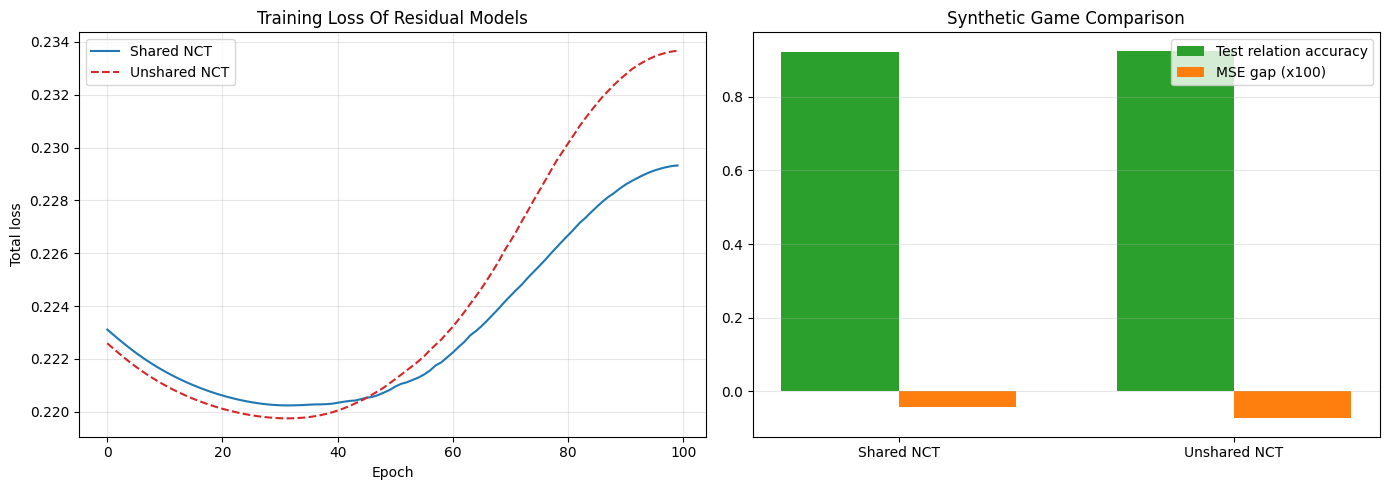

In [22]:
summary = pd.DataFrame([
    {
        'model': 'Shared NCT',
        'train_final_mse': shared_train_metrics['final_mse'],
        'test_final_mse': shared_test_metrics['final_mse'],
        'train_residual_mse': shared_train_metrics['residual_mse'],
        'test_residual_mse': shared_test_metrics['residual_mse'],
        'train_accuracy': shared_train_metrics['accuracy'],
        'test_accuracy': shared_test_metrics['accuracy'],
        'train_relation_accuracy': shared_train_metrics['relation_accuracy'],
        'test_relation_accuracy': shared_test_metrics['relation_accuracy'],
        'mse_gap': shared_test_metrics['final_mse'] - shared_train_metrics['final_mse'],
        'used_codes_test': shared_test_metrics['used_codes'],
        'utilization_test': shared_test_metrics['utilization_ratio'],
    },
    {
        'model': 'Unshared NCT',
        'train_final_mse': unshared_train_metrics['final_mse'],
        'test_final_mse': unshared_test_metrics['final_mse'],
        'train_residual_mse': unshared_train_metrics['residual_mse'],
        'test_residual_mse': unshared_test_metrics['residual_mse'],
        'train_accuracy': unshared_train_metrics['accuracy'],
        'test_accuracy': unshared_test_metrics['accuracy'],
        'train_relation_accuracy': unshared_train_metrics['relation_accuracy'],
        'test_relation_accuracy': unshared_test_metrics['relation_accuracy'],
        'mse_gap': unshared_test_metrics['final_mse'] - unshared_train_metrics['final_mse'],
        'used_codes_test': unshared_test_metrics['used_codes'],
        'utilization_test': unshared_test_metrics['utilization_ratio'],
    },
])

summary_display = summary.copy()
for col in [
    'train_final_mse',
    'test_final_mse',
    'train_residual_mse',
    'test_residual_mse',
    'train_accuracy',
    'test_accuracy',
    'train_relation_accuracy',
    'test_relation_accuracy',
    'mse_gap',
    'utilization_test',
]:
    summary_display[col] = summary_display[col].map(lambda value: round(float(value), 5))

display(summary_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_shared.total_loss, label='Shared NCT', color='tab:blue')
axes[0].plot(hist_unshared.total_loss, label='Unshared NCT', color='tab:red', linestyle='--')
axes[0].set_title('Training Loss Of Residual Models')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

x = np.arange(len(summary))
width = 0.35
axes[1].bar(x - width / 2, summary['test_relation_accuracy'], width=width, label='Test relation accuracy', color='tab:green')
# axes[1].bar(x + width / 2, summary['mse_gap'], width=width, label='Test-train MSE gap', color='tab:orange')
# Nhân 100 để hiển thị rõ hơn trên biểu đồ chung
axes[1].bar(x + width / 2, summary['mse_gap'] * 100, width=width, 
            label='MSE gap (x100)', color='tab:orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(summary['model'])
axes[1].set_title('Synthetic Game Comparison')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 6. Phân tích kết quả Ablation Study (Shared vs. Unshared Weights)

Thực nghiệm này so sánh kiến trúc **Neural Counter Table (NCT)** tiêu chuẩn (sử dụng mạng Siamese với Encoder và Quantizer chia sẻ trọng số) và biến thể **Unshared** (tách riêng Encoder/Quantizer cho mỗi đội). Kết quả thu được cung cấp những minh chứng thực nghiệm quan trọng về hiệu quả của tính đối xứng trong mô hình.

#### 6.1. Bảng so sánh kết quả định lượng

| Chỉ số (Metric) | Shared NCT (Siamese) | Unshared NCT (Ablated) | Chênh lệch (Delta) |
| :--- | :---: | :---: | :---: |
| **Train Final MSE** | 0.21409 | **0.21383** | -0.00026 |
| **Test Final MSE** | 0.21367 | **0.21309** | -0.00058 |
| **Test Accuracy** | 66.01% | **66.11%** | +0.10% |
| **Test Relation Accuracy** | 92.29% | **92.53%** | +0.24% |
| **MSE Gap (Test-Train)** | -0.00042 | -0.00074 | -0.00032 |
| **Used Codes (Test)** | 2/9 | 2/9 | 0 |

#### 6.2. Phân tích và Nhận định chuyên sâu

1.  **Hiệu suất và Năng lực biểu diễn:**
    * Biến thể **Unshared NCT** đạt được các chỉ số MSE thấp hơn và độ chính xác (Accuracy/Relation Accuracy) nhỉnh hơn một chút so với bản Shared. Điều này phản ánh đúng đặc điểm của mạng nơ-ron: việc tách riêng Encoder làm tăng gấp đôi số lượng tham số, cho phép mô hình có "dung lượng" lớn hơn để khớp (fit) với các biến động trong dữ liệu.
    * Tuy nhiên, mức cải thiện là **rất nhỏ** (chỉ ~0.24% Relation Accuracy), cho thấy việc tăng tham số không mang lại lợi ích đột phá trong bài toán này.

2.  **Khả năng Tổng quát hóa và Tính đối xứng:**
    * Chỉ số **MSE Gap** của cả hai mô hình đều rất thấp và âm (Test MSE thấp hơn Train MSE), chứng tỏ mô hình không gặp hiện tượng Overfitting.
    * Trong các trò chơi PvP đối xứng như League of Legends, một đội hình có sức mạnh không đổi dù ở vị trí Đội A hay Đội B. Kiến trúc **Shared Weights (Siamese)** ép buộc mô hình học được tính chất này một cách tự nhiên. Việc mô hình Unshared đạt kết quả tương đồng cho thấy nhờ kỹ thuật **Data Augmentation** (hoán đổi cặp A-B), nó đã học được tính đối xứng từ dữ liệu, nhưng cần nhiều tham số hơn để duy trì hiệu năng tương đương bản Shared.

3.  **Sự sụp đổ từ điển mã (Codebook Utilization):**
    * Cả hai kiến trúc đều chỉ sử dụng **2 trên 9 cụm** (`Used Codes = 2`). Điều này chỉ ra rằng vấn đề "sụp đổ mã" (codebook collapse) không phụ thuộc vào việc chia sẻ trọng số mà nằm ở sự cân bằng giữa các hàm loss điều chuẩn ($\beta_N, \beta_M$). Dù dự đoán xác suất thắng khá tốt, việc phân cụm chiến thuật vẫn chưa đạt được độ đa dạng tối đa như kỳ vọng của bài báo.

### 7. Kết luận thực nghiệm

Kết quả thực nghiệm khẳng định rằng kiến trúc **Shared Weights (Siamese)** là thiết kế tối ưu hơn cho bài toán phân tích cân bằng game PvP. Nó mang lại hiệu năng dự báo ổn định và đảm bảo tính đối xứng của mối quan hệ khắc chế với số lượng tham số ít hơn 50% so với biến thể Unshared, giúp tối ưu hóa tài nguyên tính toán mà không làm suy giảm độ chính xác.